# Prepare CO2 Concentrations

Reads annual mean CO2 concentrations from the Mauna Loa / South Pole dataset (`mlo_spo_annual_mean.csv`).
Extracts whole-year values (dropping the `.5` offset) and CO2 concentration, drops missing values,
and saves the result to `data/processed/co2/historical.pkl`.

MLO and SPO Averaged Products
yearly

https://scrippsco2.ucsd.edu/data/atmospheric_co2/averaged_products.html

Cite as: C. D. Keeling, S. C. Piper, R. B. Bacastow, M. Wahlen, T. P. Whorf, M. Heimann, and H. A. Meijer, Atmospheric CO2 and 13CO2 exchange with the terrestrial biosphere and oceans from 1978 to 2000: observations and carbon cycle implications, pages 83-113, in "A History of Atmospheric CO2 and its effects on Plants, Animals, and Ecosystems", editors, Ehleringer, J.R., T. E. Cerling, M. D. Dearing, Springer Verlag, New York, 2005.

Scripps CO2 program data and graphics on scrippsco2.ucsd.edu are licensed under a CC BY license, Creative Commons Attribution 4.0 International License (http://creativecommons.org/licenses/by/4.0/), which clarifies appropriate uses and requirements, including that credit be given to the Scripps Institution of Oceanography at UC San Diego.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from aquacrop_slovenia import config
from aquacrop_slovenia.reading_data import get_co2

In [2]:
co2_df = pd.read_csv(
    config.CO2_DIR / "mlo_spo_annual_mean.csv",
    comment="%",
    header=None,
    names=["year", "co2"],
    skipinitialspace=True,
)

co2_df.loc[:, "year"] = co2_df["year"].sub(0.5).astype(int)
co2_df = co2_df.dropna(subset=["co2"]).reset_index(drop=True)
co2_df = co2_df[co2_df["year"] >= 1981].reset_index(drop=True)

out_path = config.CO2_PROCESSED_DIR / "historical.pkl"
co2_df.to_pickle(out_path)
print(f"Saved {len(co2_df)} rows to {out_path}")
co2_df

Saved 43 rows to C:\Users\rokku\Documents\Code\aquacrop-slovenia\data\processed\co2\historical.pkl


,year,co2
0,1981.0,339.11
1,1982.0,340.28
2,1983.0,341.98
3,1984.0,343.48
4,1985.0,344.77
5,1986.0,346.16
6,1987.0,347.85
7,1988.0,350.04
8,1989.0,351.56
9,1990.0,352.84


## RCP Scenarios

Reads CO2 concentrations from the three RCP scenario files (RCP2.6/3PD, RCP4.5, RCP8.5).
Each file has 38 header rows followed by a column-name row; CO2 is the third data column.

Models in CMIP5 used the RCP CO2 concentration data from the IIASA Database

https://tntcat.iiasa.ac.at/RcpDb/

We use CO2 data from the CMIP5 recommended data section on the website of the RCP Database (Version 2.0.5)

Citation:

Meinshausen, M., S. J. Smith, K. V. Calvin, J. S. Daniel, M. L. T. Kainuma, J.-F. Lamarque, K. Matsumoto, S. A. Montzka, S. C. B. Raper, K. Riahi, A. M. Thomson, G. J. M. Velders and D. van Vuuren (2011). "The RCP Greenhouse Gas Concentrations and their Extension from 1765 to 2300." Climatic Change (Special Issue), DOI: 10.1007/s10584-011-0156-z

In [3]:
rcp_files = {
    "rcp26": config.CO2_DIR / "RCP3PD_MIDYR_CONC.DAT",
    "rcp45": config.CO2_DIR / "RCP45_MIDYR_CONC.DAT",
    "rcp85": config.CO2_DIR / "RCP85_MIDYR_CONC.DAT",
}

for scenario, path in rcp_files.items():
    df = pd.read_csv(
        path,
        skiprows=38,
        sep=r"\s+",
        engine="python",
        usecols=["YEARS", "CO2"],
    )
    df = df.rename(columns={"YEARS": "year", "CO2": "co2"})
    df.loc[:, "year"] = df["year"].astype(int)
    df = df[(df["year"] <= 2100) & (df["year"] >= 1981)].reset_index(drop=True)
    out_path = config.CO2_PROCESSED_DIR / f"{scenario}.pkl"
    df.to_pickle(out_path)
    print(f"Saved {len(df)} rows to {out_path}")
df

Saved 120 rows to C:\Users\rokku\Documents\Code\aquacrop-slovenia\data\processed\co2\rcp26.pkl
Saved 120 rows to C:\Users\rokku\Documents\Code\aquacrop-slovenia\data\processed\co2\rcp45.pkl
Saved 120 rows to C:\Users\rokku\Documents\Code\aquacrop-slovenia\data\processed\co2\rcp85.pkl


,year,co2
0,1981,339.72750
1,1982,340.79250
2,1983,342.19750
3,1984,343.78250
4,1985,345.28250
...,...,...
115,2096,899.12407
116,2097,908.28871
117,2098,917.47137
118,2099,926.66527


## Plot CO2 concentration data

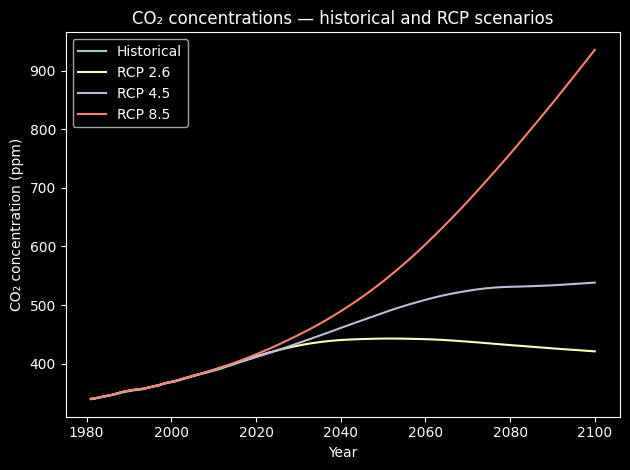

In [4]:
scenarios = {
    "Historical": "historical",
    "RCP 2.6": "rcp26",
    "RCP 4.5": "rcp45",
    "RCP 8.5": "rcp85",
}

fig, ax = plt.subplots()
for label, scenario in scenarios.items():
    df = get_co2(scenario)
    ax.plot(df["year"], df["co2"], label=label)
ax.set_xlabel("Year")
ax.set_ylabel("CO₂ concentration (ppm)")
ax.set_title("CO₂ concentrations — historical and RCP scenarios")
ax.legend()
fig.tight_layout()
plt.show()